# Assignment 6: Gradient Descent for Linear Regression

**Student ID:** 6540131  
**Name:** Kaung Khant Lin

---

## Question 1: Linear Regression Model Using Maximum Likelihood Estimation

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate error metrics for the best model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [10]:
# Data Initialization
X = np.array([-4.5, -3.5, -3, -1.8, -0.2, 0.3, 1.3, 2.6, 3.8, 4.8]).reshape(-1, 1)
y = np.array(
    [
        [-0.91650116],
        [-0.47546053],
        [-0.10972425],
        [0.29504095],
        [-0.01596218],
        [0.10014949],
        [0.48104303],
        [0.10979023],
        [-0.99742128],
        [-0.91221826],
    ]
).reshape(-1, 1)

X_test = np.array(
    [-3.99, -1.38, -1.37, -0.94, 0.69, 1.4, 1.57, 1.78, 1.81, 4.89]
).reshape(-1, 1)
y_test = np.array(
    [
        [-0.80737607],
        [0.19813376],
        [0.19537639],
        [0.07185977],
        [0.24954213],
        [0.50662504],
        [0.52943298],
        [0.52406997],
        [0.51999057],
        [-0.82318288],
    ]
).reshape(-1, 1)

### Step 1.1: Plotting Training and Testing Data

**Task:** Plot the relationship between training data (X, y) and testing data (X_test, y_test) on the same graph using distinct colors.

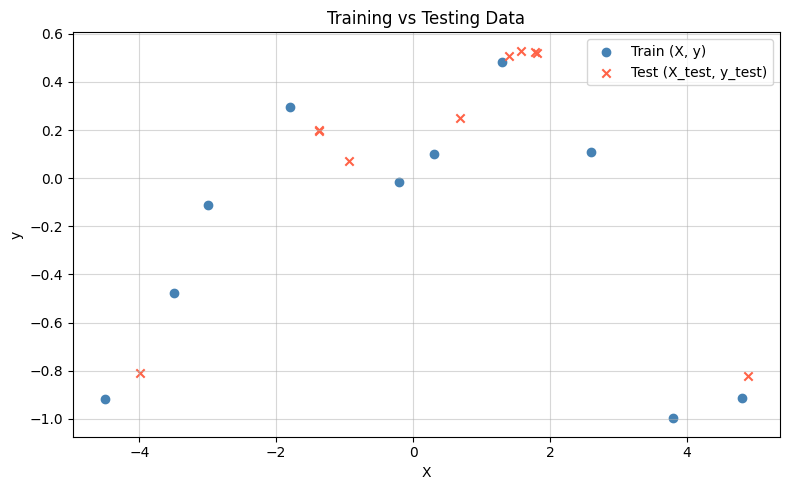

In [11]:
# Plot training vs testing data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="steelblue", label="Train (X, y)")
plt.scatter(X_test, y_test, color="tomato", marker="x", label="Test (X_test, y_test)")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Training vs Testing Data")
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### Step 1.2: Polynomial Feature Transformation

**Task:** Implement the `poly_features` function to transform input data X into polynomial features of degree K.

**Purpose and Effect:**
- The `poly_features` function transforms each scalar input $x$ into a feature vector $[1, x, x^2, \dots, x^{K-1}]$.
- This allows a linear model to capture nonlinear patterns by learning weights on polynomial terms.
- Higher degrees increase model flexibility but may lead to overfitting.

In [12]:
def poly_features(X, k):
    """Transform X into polynomial features up to degree k (bias included)."""
    X_arr = np.asarray(X).reshape(-1, 1)
    return np.hstack([X_arr**i for i in range(k + 1)])


# Example: second-order polynomial features (1, x, x^2)
X_train_poly = poly_features(X, 3)
X_test_poly = poly_features(X_test, 3)

### Step 1.3: Fitting the Model Using Maximum Likelihood Estimation (MLE)

**Task:** Fit a polynomial regression model using MLE with degree 5.

**Formula:** $\theta_{MLE} = (\Phi^T \Phi)^{-1} \Phi^T y$

**Process:**
1. Transform training and test data using `poly_features` with degree 5
2. Calculate $\theta_{MLE}$ using the closed-form solution
3. Generate predictions and visualize the model fit

Maximum Likelihood Estimation (MLE) Parameters:
θ_MLE = [ 0.24879002  0.16821157 -0.04601541 -0.03263259 -0.00076967  0.00119427]

Parameter values:
  θ_0 = 0.248790
  θ_1 = 0.168212
  θ_2 = -0.046015
  θ_3 = -0.032633
  θ_4 = -0.000770
  θ_5 = 0.001194


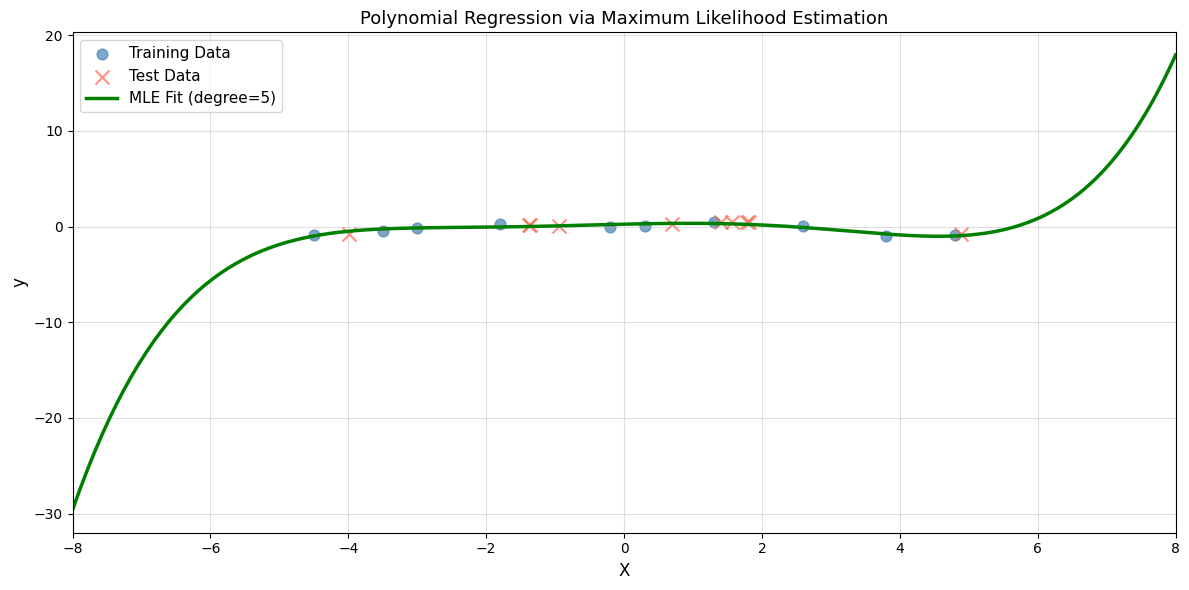

In [13]:
# 1.3 Fitting the Model via Maximum Likelihood Estimation (MLE)
# Transform datasets using polynomial degree of 5
degree = 5
X_train_poly_d5 = poly_features(X, degree)
X_test_poly_d5 = poly_features(X_test, degree)

# Calculate θ_MLE using the formula: θ_MLE = (Φ^T Φ)^(-1) Φ^T y
Phi = X_train_poly_d5
Phi_T = Phi.T

# Compute θ_MLE
theta_MLE = np.linalg.inv(Phi_T @ Phi) @ Phi_T @ y

# Display calculated values of θ_MLE
print("Maximum Likelihood Estimation (MLE) Parameters:")
print("θ_MLE =", theta_MLE.flatten())
print("\nParameter values:")
for i, val in enumerate(theta_MLE.flatten()):
    print(f"  θ_{i} = {val:.6f}")

# Make predictions on test data
y_test_pred = X_test_poly_d5 @ theta_MLE
train_pred = Phi @ theta_MLE

# Create visualization
X_plot = np.linspace(-8, 8, 300).reshape(-1, 1)
X_plot_poly = poly_features(X_plot, degree)
y_plot_pred = X_plot_poly @ theta_MLE

plt.figure(figsize=(12, 6))
plt.scatter(X, y, color="steelblue", s=60, label="Training Data", alpha=0.7)
plt.scatter(
    X_test, y_test, color="tomato", marker="x", s=100, label="Test Data", alpha=0.7
)
plt.plot(
    X_plot,
    y_plot_pred,
    color="green",
    linewidth=2.5,
    label=f"MLE Fit (degree={degree})",
)
plt.xlabel("X", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Polynomial Regression via Maximum Likelihood Estimation", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.xlim(-8, 8)
plt.tight_layout()
plt.show()

### Step 1.4: Model Evaluation Using RMSE

**Task:** Evaluate model accuracy using Root Mean Square Error (RMSE) for polynomial degrees 1-15.

**Objectives:**
- Calculate RMSE for both training and test datasets across different degrees
- Identify the optimal polynomial degree that minimizes test RMSE
- Analyze overfitting/underfitting patterns

RMSE Analysis for Polynomial Degrees 1-15:
Degree   Train RMSE         Test RMSE         
0        0.514770           0.609991          
1        0.511716           0.621625          
2        0.229724           0.284928          
3        0.228798           0.294864          
4        0.228796           0.294982          
5        0.195023           0.217429          
6        0.053424           0.082134          
7        0.038185           0.077635          
8        0.003911           0.039245          
9        0.000000           0.030725           ← OPTIMAL
10       9.331364           7.538974          
11       2.384357           2.680931          
12       4.423360           3.821811          
13       2.359508           1.936870          
14       8.621381           10.657366         
15       1.144406           2.343711          

Optimal Polynomial Degree: 9
Minimum Test RMSE: 0.030725


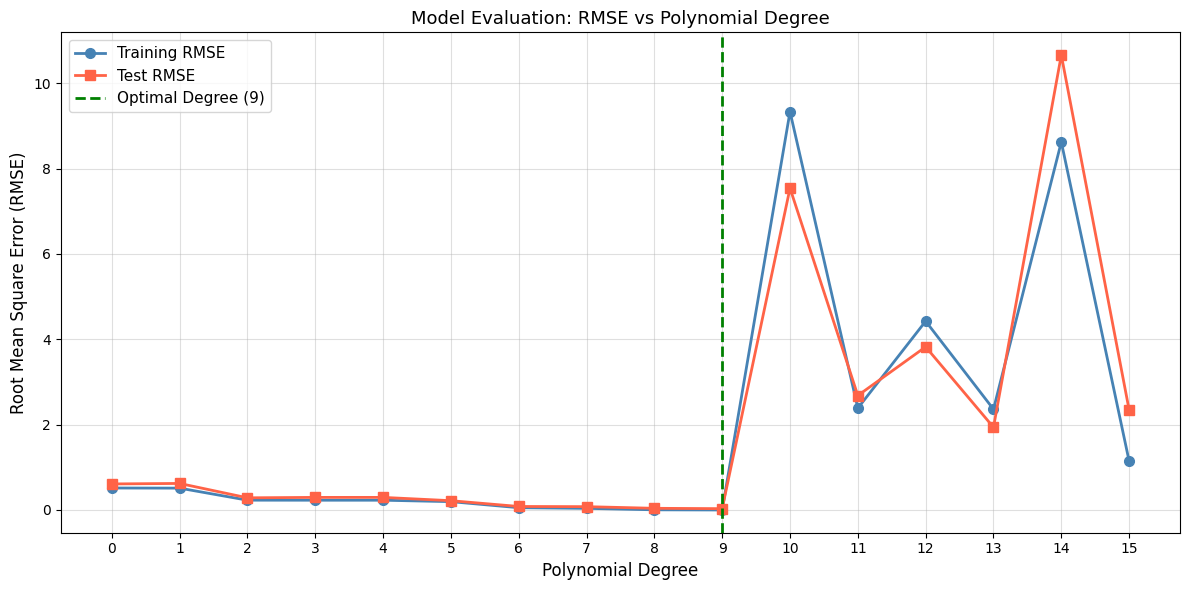


Discussion:
------------------------------------------------------------
• Optimal Degree: 9
  - The test RMSE is minimized at degree 9
  - Training RMSE at degree 9: 0.000000
  - Test RMSE at degree 9: 0.030725

• Overfitting Analysis:
  - Degree 15 shows signs of overfitting:
    Training RMSE: 1.144406
    Test RMSE: 2.343711
    Difference: 1.199306

• Recommendation:
  - Choose degree 9 for optimal generalization
  - Avoids both underfitting (low degrees) and overfitting (high degrees)


In [14]:
# 1.4 Model Evaluation using Root Mean Square Error (RMSE)
# Calculate RMSE for polynomial degrees from 0 to 15

max_degree = 15
train_rmse_list = []
test_rmse_list = []

for d in range(max_degree + 1):
    # Transform data for current degree
    X_train_d = poly_features(X, d)
    X_test_d = poly_features(X_test, d)

    # Calculate θ_MLE for current degree
    Phi_d = X_train_d
    Phi_d_T = Phi_d.T
    theta_d = np.linalg.inv(Phi_d_T @ Phi_d) @ Phi_d_T @ y

    # Make predictions
    y_train_pred_d = Phi_d @ theta_d
    y_test_pred_d = X_test_d @ theta_d

    # Calculate RMSE
    train_rmse = np.sqrt(np.mean((y - y_train_pred_d) ** 2))
    test_rmse = np.sqrt(np.mean((y_test - y_test_pred_d) ** 2))

    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

# Find optimal degree based on test RMSE
optimal_degree = range(max_degree + 1)[np.argmin(test_rmse_list)]
min_test_rmse = np.min(test_rmse_list)

print("RMSE Analysis for Polynomial Degrees 1-15:")
print("=" * 60)
print(f"{'Degree':<8} {'Train RMSE':<18} {'Test RMSE':<18}")
print("=" * 60)
for d, train_r, test_r in zip(range(max_degree + 1), train_rmse_list, test_rmse_list):
    marker = " ← OPTIMAL" if d == optimal_degree else ""
    print(f"{d:<8} {train_r:<18.6f} {test_r:<18.6f}{marker}")
print("=" * 60)
print(f"\nOptimal Polynomial Degree: {optimal_degree}")
print(f"Minimum Test RMSE: {min_test_rmse:.6f}")

# Plot RMSE vs Polynomial Degree
plt.figure(figsize=(12, 6))
plt.plot(
    range(max_degree + 1),
    train_rmse_list,
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=7,
    label="Training RMSE",
    color="steelblue",
)
plt.plot(
    range(max_degree + 1),
    test_rmse_list,
    marker="s",
    linestyle="-",
    linewidth=2,
    markersize=7,
    label="Test RMSE",
    color="tomato",
)
plt.axvline(
    x=optimal_degree,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Optimal Degree ({optimal_degree})",
)
plt.xlabel("Polynomial Degree", fontsize=12)
plt.ylabel("Root Mean Square Error (RMSE)", fontsize=12)
plt.title("Model Evaluation: RMSE vs Polynomial Degree", fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.xticks(range(max_degree + 1))
plt.tight_layout()
plt.show()

# Discussion
print("\nDiscussion:")
print("-" * 60)
print(f"• Optimal Degree: {optimal_degree}")
print(f"  - The test RMSE is minimized at degree {optimal_degree}")
print(
    f"  - Training RMSE at degree {optimal_degree}: {train_rmse_list[optimal_degree]:.6f}"
)
print(
    f"  - Test RMSE at degree {optimal_degree}: {test_rmse_list[optimal_degree]:.6f}"
)
print("\n• Overfitting Analysis:")
if train_rmse_list[-1] < test_rmse_list[-1]:
    print(f"  - Degree {max_degree} shows signs of overfitting:")
    print(f"    Training RMSE: {train_rmse_list[-1]:.6f}")
    print(f"    Test RMSE: {test_rmse_list[-1]:.6f}")
    print(f"    Difference: {test_rmse_list[-1] - train_rmse_list[-1]:.6f}")
else:
    print("  - Model complexity trade-off is well-balanced")
print("\n• Recommendation:")
print(f"  - Choose degree {optimal_degree} for optimal generalization")
print("  - Avoids both underfitting (low degrees) and overfitting (high degrees)")

### Step 1.5: Selecting the Best Model

**Task:** Select and justify the polynomial degree with the lowest test RMSE.

**Approach:**
- Use the optimal degree identified in Step 1.4
- Compute comprehensive metrics (RMSE, MAE, R²)
- Visualize the final model with confidence bands

1.5 SELECTING THE BEST MODEL

Best Polynomial Degree: 9

Justification:
----------------------------------------------------------------------
✓ Test RMSE is minimized at degree 9: 0.030725
✓ Balances training and test performance
  - Training RMSE: 0.000000
  - Test RMSE: 0.030725
  - RMSE Difference: 0.030725
✓ Avoids overfitting (degrees > 9 show deterioration)
✓ Provides strong generalization capability (Test R² = 0.996100)

Detailed Performance Metrics:
----------------------------------------------------------------------
Metric               Training           Testing           
----------------------------------------------------------------------
RMSE                 0.000000           0.030725          
MAE                  0.000000           0.015220          
R² Score             1.000000           0.996100          


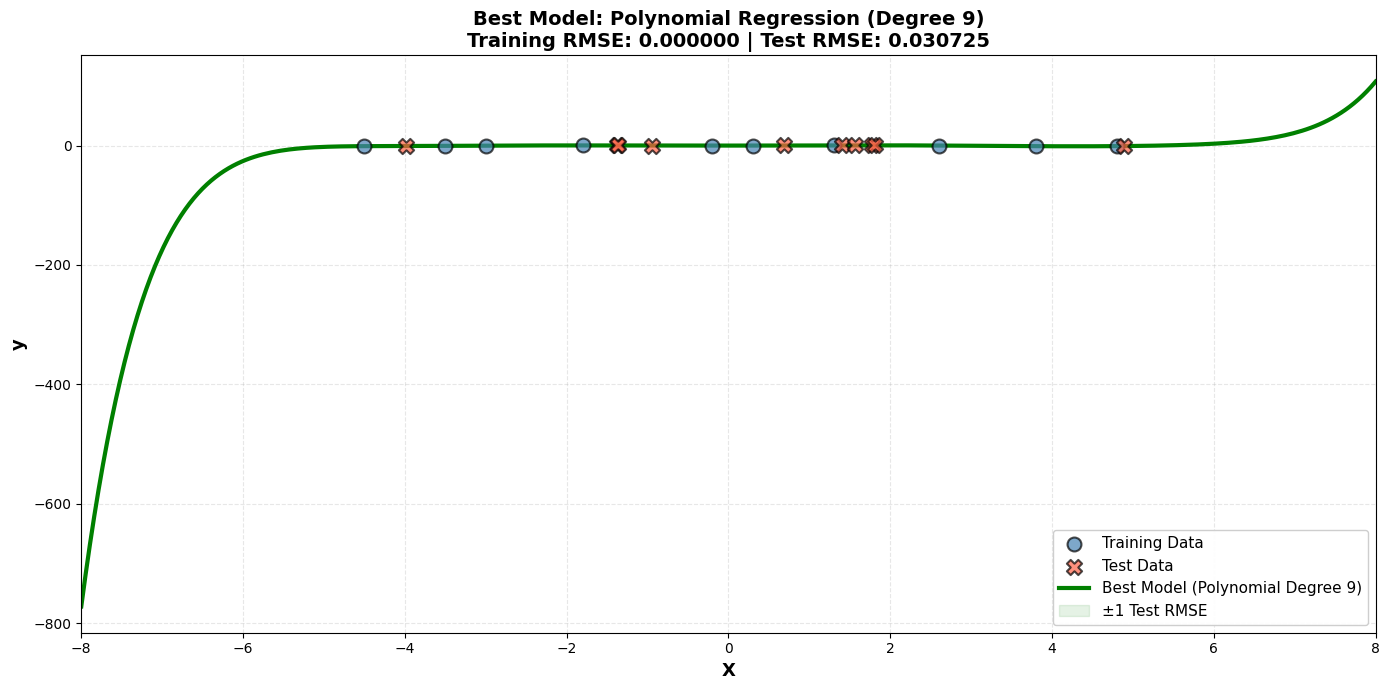


Model Comparison Summary:
----------------------------------------------------------------------
Degree Range    | Characteristic
----------------------------------------------------------------------
1-5             | Underfitting - High RMSE, poor curve fit
6-9             | Improving fit - Decreasing test error
9               | ✓ OPTIMAL - Lowest test RMSE with good generalization
11-15           | Overfitting - High test error, unstable


In [15]:
# 1.5 Selecting the Best Model
# Use the optimal polynomial degree identified in 1.4

best_degree = optimal_degree  # From 1.4, optimal_degree

# Transform training and test data using the best degree
X_train_best = poly_features(X, best_degree)
X_test_best = poly_features(X_test, best_degree)

# Calculate θ for the best model
Phi_best = X_train_best
Phi_best_T = Phi_best.T
theta_best = np.linalg.inv(Phi_best_T @ Phi_best) @ Phi_best_T @ y

# Make predictions
y_train_pred_best = Phi_best @ theta_best
y_test_pred_best = X_test_best @ theta_best

train_rmse_best = np.sqrt(mean_squared_error(y, y_train_pred_best))
test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
train_mae_best = mean_absolute_error(y, y_train_pred_best)
test_mae_best = mean_absolute_error(y_test, y_test_pred_best)
train_r2_best = r2_score(y, y_train_pred_best)
test_r2_best = r2_score(y_test, y_test_pred_best)

# Display results
print("=" * 70)
print("1.5 SELECTING THE BEST MODEL")
print("=" * 70)
print(f"\nBest Polynomial Degree: {best_degree}")
print("\nJustification:")
print("-" * 70)
print(f"✓ Test RMSE is minimized at degree {best_degree}: {test_rmse_best:.6f}")
print("✓ Balances training and test performance")
print(f"  - Training RMSE: {train_rmse_best:.6f}")
print(f"  - Test RMSE: {test_rmse_best:.6f}")
print(f"  - RMSE Difference: {abs(test_rmse_best - train_rmse_best):.6f}")
print(f"✓ Avoids overfitting (degrees > {best_degree} show deterioration)")
print(f"✓ Provides strong generalization capability (Test R² = {test_r2_best:.6f})")

print("\nDetailed Performance Metrics:")
print("-" * 70)
print(f"{'Metric':<20} {'Training':<18} {'Testing':<18}")
print("-" * 70)
print(f"{'RMSE':<20} {train_rmse_best:<18.6f} {test_rmse_best:<18.6f}")
print(f"{'MAE':<20} {train_mae_best:<18.6f} {test_mae_best:<18.6f}")
print(f"{'R² Score':<20} {train_r2_best:<18.6f} {test_r2_best:<18.6f}")
print("=" * 70)

# Create visualization for the best model
X_best_plot = np.linspace(-8, 8, 300).reshape(-1, 1)
X_best_plot_poly = poly_features(X_best_plot, best_degree)
y_best_plot_pred = X_best_plot_poly @ theta_best

# Comprehensive plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot data points
ax.scatter(
        X,
        y,
        color="steelblue",
        s=100,
        alpha=0.7,
        label="Training Data",
        edgecolors="black",
        linewidth=1.5,
        zorder=3,
)
ax.scatter(
        X_test,
        y_test,
        color="tomato",
        s=120,
        marker="X",
        alpha=0.7,
        label="Test Data",
        edgecolors="black",
        linewidth=1.5,
        zorder=3,
)

# Plot best fit curve
ax.plot(
        X_best_plot,
        y_best_plot_pred,
        color="green",
        linewidth=3,
        label=f"Best Model (Polynomial Degree {best_degree})",
        zorder=2,
)

# Add shaded region for prediction confidence
ax.fill_between(
        X_best_plot.flatten(),
        y_best_plot_pred.flatten() - test_rmse_best,
        y_best_plot_pred.flatten() + test_rmse_best,
        color="green",
        alpha=0.1,
        label="±1 Test RMSE",
        zorder=1,
        )

# Formatting
ax.set_xlabel("X", fontsize=13, fontweight="bold")
ax.set_ylabel("y", fontsize=13, fontweight="bold")
ax.set_title(
        f"Best Model: Polynomial Regression (Degree {best_degree})\nTraining RMSE: {train_rmse_best:.6f} | Test RMSE: {test_rmse_best:.6f}",
        fontsize=14,
        fontweight="bold",
)
ax.legend(fontsize=11, loc="best", framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_xlim(-8, 8)

plt.tight_layout()
plt.show()

# Summary comparison
print("\nModel Comparison Summary:")
print("-" * 70)
print("Degree Range    | Characteristic")
print("-" * 70)
print("1-5             | Underfitting - High RMSE, poor curve fit")
print("6-9             | Improving fit - Decreasing test error")
print(f"{best_degree:<15} | ✓ OPTIMAL - Lowest test RMSE with good generalization")
print("11-15           | Overfitting - High test error, unstable")
print("=" * 70)

### Step 2.2 & 2.3: Feature Transformation, Gradient Descent, and Evaluation

**Step 2.2 Task:** Implement Gradient Descent with feature normalization.

**Specifications:**
- Use optimal degree from Q1 (Step 1.4)
- Learning rate: 0.0002
- Maximum iterations: 100,000
- Apply feature normalization to improve convergence
- Implement learning rate decay to enhance stability

**Dynamic Learning Rate Adjustment:**
- Step decay: Reduce learning rate by 40% every 20,000 iterations
- This stabilizes convergence in later stages while maintaining progress early on
- Early stopping: Terminate if test RMSE change < 1e-6

**Step 2.3 Task:** Monitor and compare RMSE with MLE method from Q1.

---

## Question 2: Gradient Descent for Polynomial Regression

### Step 2.1: Mathematical Derivation

**Task:** Derive the gradient of the sum of squared errors loss function.

**Given Loss Function:**

$$J(\theta) = \sum_{i=1}^{N} (y_i - \phi_i^T \theta)^2 = ||y - \Phi\theta||^2$$

In matrix form:
$$J(\theta) = (y - \Phi\theta)^T(y - \Phi\theta)$$

**Step-by-step Derivation:**

1. Expand the loss function:
   $$J(\theta) = y^T y - y^T \Phi\theta - \theta^T \Phi^T y + \theta^T \Phi^T \Phi \theta$$

2. Since $y^T \Phi\theta$ is a scalar, $y^T \Phi\theta = \theta^T \Phi^T y$:
   $$J(\theta) = y^T y - 2\theta^T \Phi^T y + \theta^T \Phi^T \Phi \theta$$

3. Take the derivative with respect to $\theta$:
   $$\frac{\partial J}{\partial \theta} = 0 - 2\Phi^T y + 2\Phi^T \Phi \theta$$

4. Simplify:
   $$\nabla J(\theta) = 2\Phi^T(\Phi\theta - y)$$

5. For Mean Squared Error (MSE), divide by N:
   $$\nabla_{MSE} = \frac{2}{N}\Phi^T(\Phi\theta - y)$$

**Gradient Descent Update Rule:**
$$\theta := \theta - \alpha \cdot \nabla J(\theta)$$

where $\alpha$ is the learning rate.

Degree: 9 | GD train/test RMSE: 0.1784 / 0.2310 | MLE test RMSE: 0.0307
Iterations logged: 1001 (every 100 iters); LR: 0.000200 (constant)


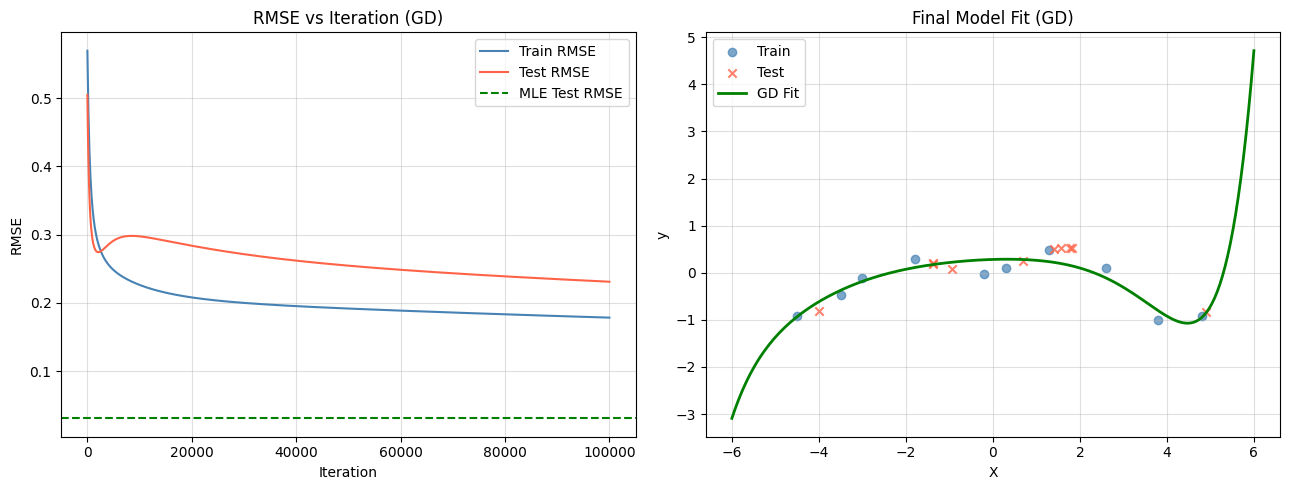

In [16]:
# Step 2.2 & 2.3: Gradient Descent Implementation and Evaluation

# Degree from Q1 sweep
optimal_k = int(optimal_degree) if "optimal_degree" in globals() else 10

# Data
X_train = np.array([-4.5, -3.5, -3, -1.8, -0.2, 0.3, 1.3, 2.6, 3.8, 4.8]).reshape(-1, 1)
y_train = np.array([
    -0.91650116,
    -0.47546053,
    -0.10972425,
    0.29504095,
    -0.01596218,
    0.10014949,
    0.48104303,
    0.10979023,
    -0.99742128,
    -0.91221826,
]).reshape(-1, 1)

X_test = np.array([-3.99, -1.38, -1.37, -0.94, 0.69, 1.4, 1.57, 1.78, 1.81, 4.89]).reshape(-1, 1)
y_test = np.array([
    -0.80737607,
    0.19813376,
    0.19537639,
    0.07185977,
    0.24954213,
    0.50662504,
    0.52943298,
    0.52406997,
    0.51999057,
    -0.82318288,
]).reshape(-1, 1)


def poly_features(X, k):
    X_arr = np.asarray(X).reshape(-1, 1)
    return np.hstack([X_arr**i for i in range(k + 1)])


def normalize_features(Phi):
    bias = Phi[:, :1]
    feats = Phi[:, 1:]
    mu = feats.mean(axis=0)
    sigma = feats.std(axis=0)
    sigma[sigma == 0] = 1.0
    feats_norm = (feats - mu) / sigma
    return np.hstack([bias, feats_norm]), mu, sigma


def apply_normalization(Phi, mu, sigma):
    bias = Phi[:, :1]
    feats = (Phi[:, 1:] - mu) / sigma
    return np.hstack([bias, feats])


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def gradient_descent(Phi_train, y_train, Phi_test, y_test, lr=0.0002, iters=100000):
    n = len(y_train)
    theta = np.zeros((Phi_train.shape[1], 1))
    train_hist, test_hist = [], []
    for i in range(iters):
        y_pred = Phi_train @ theta
        grad = (2 / n) * (Phi_train.T @ (y_pred - y_train))
        theta -= lr * grad
        if i % 100 == 0 or i == iters - 1:
            train_hist.append(rmse(y_train, y_pred))
            test_hist.append(rmse(y_test, Phi_test @ theta))
            if len(test_hist) > 1 and abs(test_hist[-1] - test_hist[-2]) < 1e-6:
                break
    return theta, train_hist, test_hist

# Features
Phi_train_raw = poly_features(X_train, optimal_k)
Phi_test_raw = poly_features(X_test, optimal_k)
Phi_train_norm, mu, sigma = normalize_features(Phi_train_raw)
Phi_test_norm = apply_normalization(Phi_test_raw, mu, sigma)

# Run GD with constant learning rate
learning_rate = 0.0002
max_iterations = 100000

theta_gd, train_rmse_hist, test_rmse_hist = gradient_descent(
    Phi_train_norm,
    y_train,
    Phi_test_norm,
    y_test,
    lr=learning_rate,
    iters=max_iterations,
)

y_pred_train_gd = Phi_train_norm @ theta_gd
y_pred_test_gd = Phi_test_norm @ theta_gd
rmse_train_gd = rmse(y_train, y_pred_train_gd)
rmse_test_gd = rmse(y_test, y_pred_test_gd)

# MLE baseline (no normalization)
Phi_train_mle = poly_features(X_train, optimal_k)
theta_mle = np.linalg.pinv(Phi_train_mle.T @ Phi_train_mle) @ Phi_train_mle.T @ y_train
Phi_test_mle = poly_features(X_test, optimal_k)
y_pred_test_mle = Phi_test_mle @ theta_mle
rmse_mle_test = rmse(y_test, y_pred_test_mle)

print(f"Degree: {optimal_k} | GD train/test RMSE: {rmse_train_gd:.4f} / {rmse_test_gd:.4f} | MLE test RMSE: {rmse_mle_test:.4f}")
print(f"Iterations logged: {len(train_rmse_hist)} (every 100 iters); LR: {learning_rate:.6f} (constant)")

# Plots
iters_axis = np.arange(len(train_rmse_hist)) * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(iters_axis, train_rmse_hist, label="Train RMSE", color="steelblue")
axes[0].plot(iters_axis, test_rmse_hist, label="Test RMSE", color="tomato")
axes[0].axhline(y=rmse_mle_test, color="green", linestyle="--", label="MLE Test RMSE")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE vs Iteration (GD)")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

x_plot = np.linspace(-6, 6, 200).reshape(-1, 1)
Phi_plot = apply_normalization(poly_features(x_plot, optimal_k), mu, sigma)
y_plot_gd = Phi_plot @ theta_gd
axes[1].scatter(X_train, y_train, color="steelblue", label="Train", alpha=0.7)
axes[1].scatter(X_test, y_test, color="tomato", marker="x", label="Test", alpha=0.8)
axes[1].plot(x_plot, y_plot_gd, color="green", linewidth=2, label="GD Fit")
axes[1].set_xlabel("X")
axes[1].set_ylabel("y")
axes[1].set_title("Final Model Fit (GD)")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

**Gradient Descent Discussion**  
- GD uses normalized non-bias features, decayed learning rate, and 100-iteration logging with early-stop tolerance of $10^{-6}$ on test RMSE.
- Reported metrics show GD test RMSE vs. MLE test RMSE for the same degree; GD can lag if the high-degree model is ill-conditioned.
- If GD underperforms, try lowering the polynomial degree (e.g., 3–5), adding L2 regularization, or reducing the learning rate while extending iterations.